# Garmin data exploration

Self-contained EDA over the Garmin export. Unit conversions here mirror what the
`marathon.parse` package will formalize (distance cm, duration ms, `avgSpeed * 10 = m/s`,
timestamps ms-epoch UTC). Exploration only: anything reusable should move into `src/marathon/`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return start


ROOT = find_root()
CONNECT = ROOT / "data" / "DI_CONNECT"
METRICS = CONNECT / "DI-Connect-Metrics"
print("repo root:", ROOT)

repo root: /Users/jvc/src/marathon-performance-predictor


## Load activities (completed workouts)

In [2]:
DISCIPLINE = {
    "running": "run", "treadmill_running": "run", "trail_running": "run",
    "road_biking": "bike", "virtual_ride": "bike", "indoor_cycling": "bike", "cycling": "bike",
    "lap_swimming": "swim", "open_water_swimming": "swim",
    "strength_training": "strength",
    "indoor_cardio": "cardio", "indoor_rowing": "cardio", "pilates": "cardio",
}

act_file = next((CONNECT / "DI-Connect-Fitness").glob("*_summarizedActivities.json"))
raw = json.loads(act_file.read_text())[0]["summarizedActivitiesExport"]


def to_df(raw: list[dict]) -> pd.DataFrame:
    rows = []
    for a in raw:
        dist_km = (a.get("distance") or 0) / 100_000 or np.nan
        dur_s = (a.get("duration") or 0) / 1000 or np.nan
        rows.append({
            "activity_id": a.get("activityId"),
            "name": a.get("name"),
            "activity_type": a.get("activityType"),
            "discipline": DISCIPLINE.get(a.get("activityType"), "other"),
            "start": pd.to_datetime(a.get("beginTimestamp"), unit="ms", utc=True),
            "distance_km": dist_km,
            "duration_s": dur_s,
            "pace_s_per_km": (dur_s / dist_km) if (dist_km and dist_km > 0) else np.nan,
            "avg_speed_ms": (a.get("avgSpeed") or np.nan) * 10,
            "avg_hr": a.get("avgHr"),
            "max_hr": a.get("maxHr"),
            "vo2max": a.get("vO2MaxValue"),
            "training_load": a.get("activityTrainingLoad"),
            "elevation_gain_m": (a.get("elevationGain") or np.nan) / 100,
            "is_race": a.get("eventTypeId") == 1,
            "is_parent": bool(a.get("parent", False)),
        })
    return pd.DataFrame(rows).sort_values("start").reset_index(drop=True)


df = to_df(raw)
print(df.shape)
df.head()

(581, 16)


,activity_id,name,activity_type,discipline,start,distance_km,duration_s,pace_s_per_km,avg_speed_ms,avg_hr,max_hr,vo2max,training_load,elevation_gain_m,is_race,is_parent
0,15309315325,Madrid - 5km easy run,running,run,2024-05-09 17:11:01+00:00,7.35631,2773.395020,377.008989,2.652,132.0,142.0,55.0,38.584167,8.57,False,False
1,15319961684,Cardio,indoor_cardio,cardio,2024-05-10 12:04:40+00:00,NaN,254.634003,NaN,NaN,121.0,135.0,NaN,6.012848,NaN,False,False
2,15321393985,Fuerza,strength_training,strength,2024-05-10 12:10:30+00:00,NaN,5422.565918,NaN,NaN,107.0,156.0,NaN,34.045471,NaN,False,False
3,15337386629,Madrid - Base,running,run,2024-05-11 11:22:07+00:00,7.04445,2408.274902,341.868398,2.925,149.0,170.0,55.0,102.306503,80.81,False,False
4,15362552294,Madrid - Base,running,run,2024-05-12 18:53:39+00:00,5.44747,1806.401978,331.603828,3.016,144.0,154.0,55.0,67.009521,3.59,False,False


## Overview: what's in the export

In [3]:
print("date span:", df["start"].min().date(), "->", df["start"].max().date())
print("activities:", len(df), "| races:", int(df["is_race"].sum()))
df["discipline"].value_counts()

date span: 2024-05-09 -> 2026-06-01
activities: 581 | races: 6


discipline
run         272
strength    137
bike         71
swim         52
cardio       34
other        15
Name: count, dtype: int64

## Running focus
Labels for the race predictor come from runs only. Quick distribution.

In [4]:
runs = df[(df["discipline"] == "run") & (df["distance_km"] > 0.5)].copy()
print("usable runs:", len(runs))
runs[["distance_km", "duration_s", "pace_s_per_km", "avg_hr", "vo2max", "training_load"]].describe()

usable runs: 270


,distance_km,duration_s,pace_s_per_km,avg_hr,vo2max,training_load
count,270.000000,270.000000,270.000000,270.000000,251.000000,270.000000
mean,8.382129,2647.603011,322.746768,141.088889,57.601594,113.937255
std,4.520565,1341.754144,40.312428,11.485868,1.203594,79.088679
min,0.605140,238.188995,236.892610,99.000000,55.000000,8.366837
25%,5.776542,1858.015747,302.607104,135.000000,57.000000,65.731567
50%,7.472755,2392.427002,317.385164,142.000000,58.000000,88.358124
75%,9.699730,3006.039307,333.331103,147.000000,59.000000,145.730236
max,33.264422,9151.217773,589.063352,180.000000,60.000000,531.551575


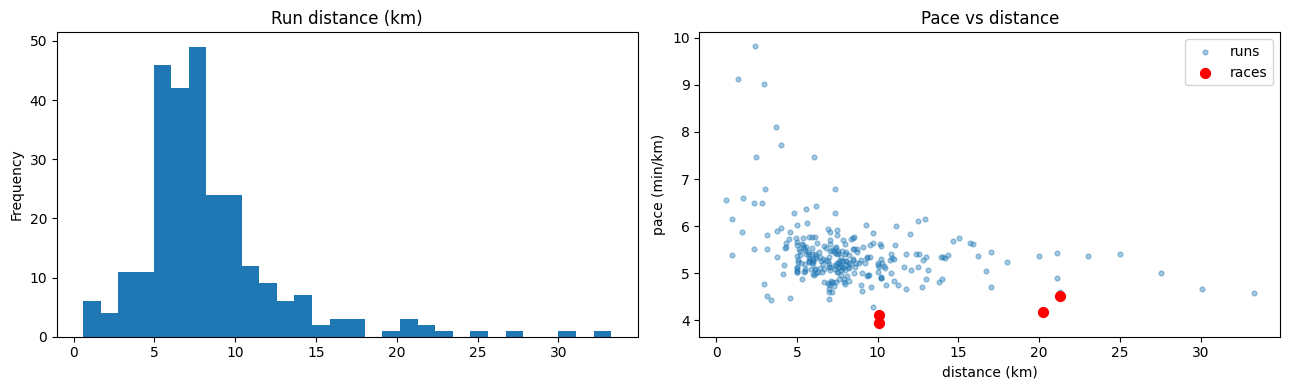

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
runs["distance_km"].plot.hist(bins=30, ax=ax[0], title="Run distance (km)")
ax[1].scatter(runs["distance_km"], runs["pace_s_per_km"] / 60, s=12, alpha=0.4, label="runs")
r = runs[runs["is_race"]]
ax[1].scatter(r["distance_km"], r["pace_s_per_km"] / 60, color="red", s=50, label="races")
ax[1].set(xlabel="distance (km)", ylabel="pace (min/km)", title="Pace vs distance")
ax[1].legend()
plt.tight_layout()

Text(0, 0.5, 'km')

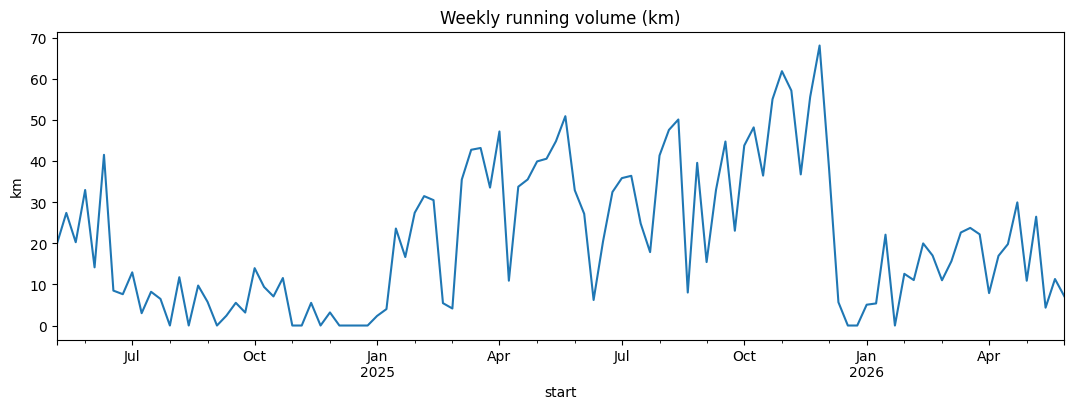

In [6]:
weekly_km = runs.set_index("start")["distance_km"].resample("W").sum()
weekly_km.plot(figsize=(13, 4), title="Weekly running volume (km)")
plt.ylabel("km")

## Multisport training load
Daily load summed across all disciplines (parents excluded to avoid double-counting multi-sport legs). This is the systemic-fatigue signal CTL/ATL/TSB will be built from.

Text(0, 0.5, 'training load')

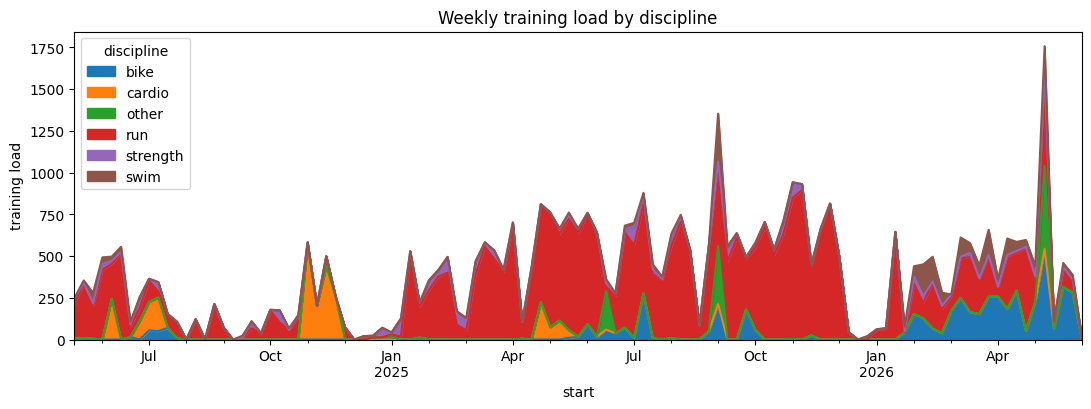

In [7]:
load = df[~df["is_parent"]].copy()
by_disc = (
    load.set_index("start")
    .groupby("discipline")["training_load"]
    .resample("W")
    .sum()
    .unstack("discipline")
    .fillna(0)
)
by_disc.plot.area(figsize=(13, 4), title="Weekly training load by discipline")
plt.ylabel("training load")

## Garmin CTL / ATL / TSB (to validate our own recompute against)

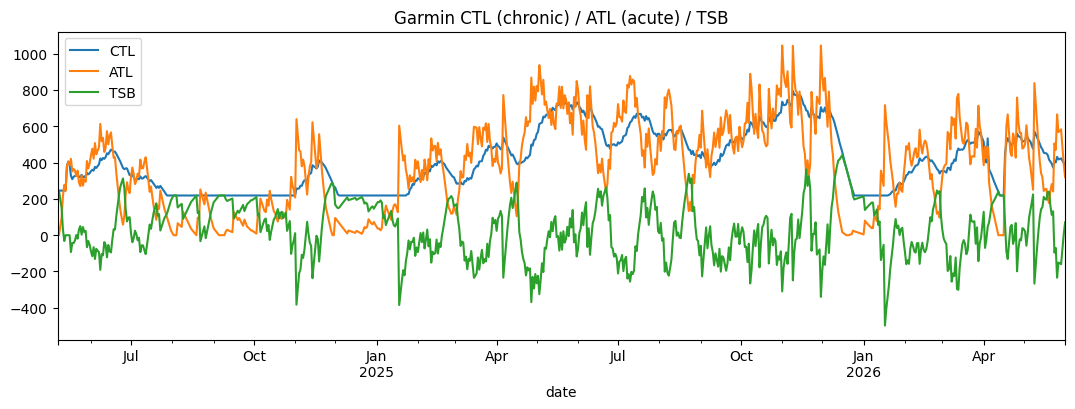

In [8]:
atl = pd.concat(
    [pd.DataFrame(json.loads(f.read_text())) for f in sorted(METRICS.glob("MetricsAcuteTrainingLoad_*.json"))],
    ignore_index=True,
)
atl["date"] = pd.to_datetime(atl["calendarDate"], unit="ms")
atl = atl.drop_duplicates("date", keep="last").sort_values("date")
atl["tsb"] = atl["dailyTrainingLoadChronic"] - atl["dailyTrainingLoadAcute"]
ax = atl.set_index("date")[["dailyTrainingLoadChronic", "dailyTrainingLoadAcute", "tsb"]].plot(
    figsize=(13, 4), title="Garmin CTL (chronic) / ATL (acute) / TSB"
)
ax.legend(["CTL", "ATL", "TSB"])

## Garmin race-time predictions (the baseline to beat)

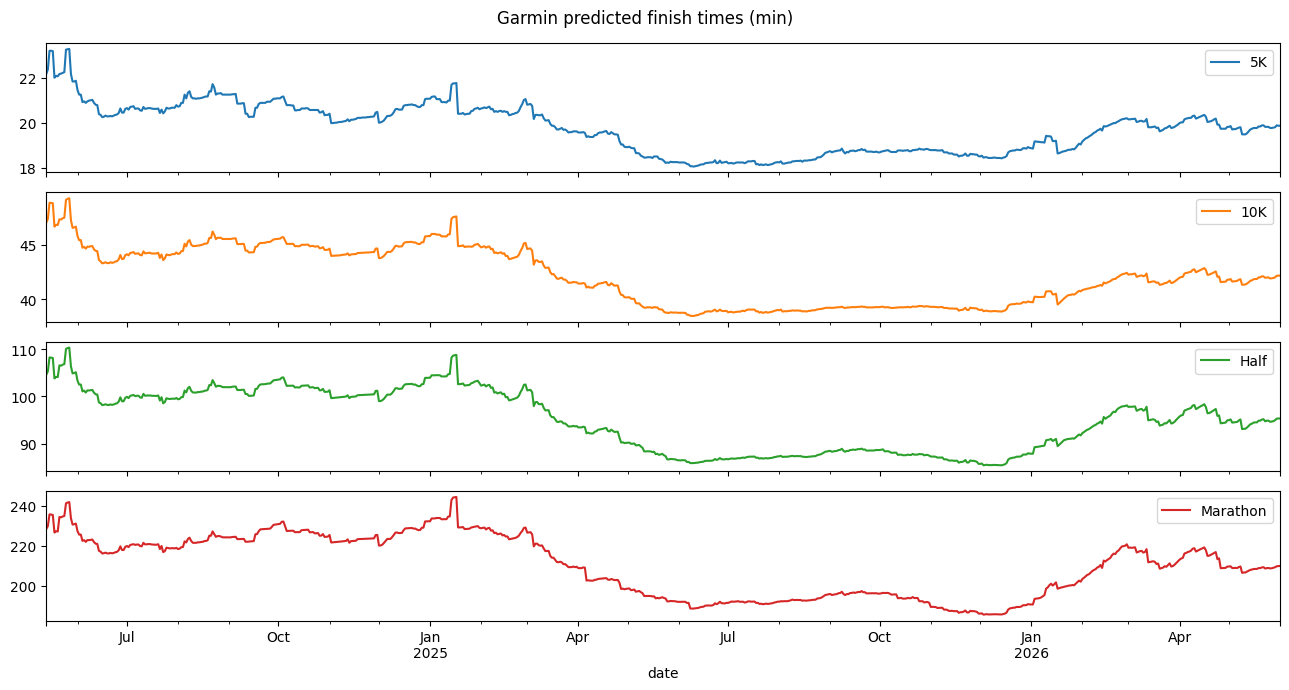

In [9]:
rrp = pd.concat(
    [pd.DataFrame(json.loads(f.read_text())) for f in sorted(METRICS.glob("RunRacePredictions_*.json"))],
    ignore_index=True,
)
rrp["date"] = pd.to_datetime(rrp["calendarDate"])
rrp = rrp.drop_duplicates("date", keep="last").sort_values("date")
for col, lab in [("raceTime5K", "5K"), ("raceTime10K", "10K"), ("raceTimeHalf", "Half"), ("raceTimeMarathon", "Marathon")]:
    rrp[lab] = rrp[col] / 60
rrp.set_index("date")[["5K", "10K", "Half", "Marathon"]].plot(
    subplots=True, figsize=(13, 7), title="Garmin predicted finish times (min)"
)
plt.tight_layout()

## Velocity-duration view
The race predictor fits a personalized speed-vs-duration curve. Races (red) anchor the fast edge; everyday runs fill the interior.

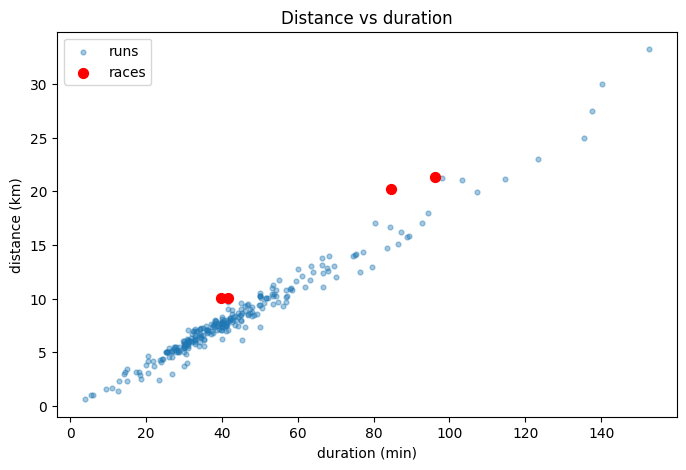

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(runs["duration_s"] / 60, runs["distance_km"], s=12, alpha=0.4, label="runs")
r = runs[runs["is_race"]]
plt.scatter(r["duration_s"] / 60, r["distance_km"], color="red", s=50, label="races")
plt.xlabel("duration (min)")
plt.ylabel("distance (km)")
plt.title("Distance vs duration")
plt.legend()

## Notes
- `summarizedActivities` has avg/max HR, distance, duration, load, VO2max, cadence, power, HR-zone times. Per-second detail (GPS track, per-second HR) lives in the FIT zips under `DI-Connect-Uploaded-Files/` if ever needed.
- Multi-sport rows have `parent == True` and double-count their legs' load: exclude them.
- `eventTypeId == 1` flags real races: clean 10K / Half / 20K anchors for the curve.